# Roman-Empire Sparsification — Analysis & Hypothesis Testing

> **Dataset:** Roman-empire (Platonov et al., ICLR 2023)  
> 22,662 nodes · 65,854 edges · 300 features · 18 classes · homophily ≈ 0.047

**Prerequisites:** Run the experiment script to produce the three result files:

```bash
nohup caffeinate -i .venv/bin/python scripts/nb05_roman_empire/roman_empire_gpu.py \
    > logs/roman_empire.log 2>&1 &
```

Outputs expected in `results/`:
- `roman_empire_hpo_results.csv`
- `roman_empire_results.csv`
- `roman_empire_baselines.json`

This notebook is **read-only with respect to training** — it only loads saved
results and runs analysis. A full top-to-bottom run takes < 1 minute.


In [1]:
import json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

NOTEBOOK_DIR = Path('.')
RESULTS_DIR  = (Path('..') / '..').resolve() / 'results'
ROMAIN_DIR   = RESULTS_DIR / 'roman_empire'
print('Imports OK')
print(f'Results dir : {RESULTS_DIR}')


Imports OK
Results dir : /Users/ilias/Library/CloudStorage/ProtonDrive-iliaslkl@proton.me-folder/Documents/GitHub/gnn-sparsification-research/results


In [2]:
# Static configuration — must match 05_Roman_Empire_Sparsification_Analysis.ipynb
GLOBAL_SEED = 42
N_SPLITS    = 10

RETENTION_RATES = [0.9, 0.8, 0.6, 0.4, 0.2]

# (label, metric, keep_lowest, weighted, variant)
SPARSIFICATION_CONFIGS = [
    ('Random',          'random',         False, False, 'threshold'),
    ('Jaccard-T',       'jaccard',        False, False, 'threshold'),
    ('AA-T',            'adamic_adar',    False, False, 'threshold'),
    ('ApproxER-T',      'approx_er',      False, False, 'threshold'),
    ('FeatCos-T',       'feature_cosine', False, False, 'threshold'),
    ('Jaccard-IT',      'jaccard',        True,  False, 'threshold'),
    ('AA-IT',           'adamic_adar',    True,  False, 'threshold'),
    ('ApproxER-IT',     'approx_er',      True,  False, 'threshold'),
    ('FeatCos-IT',      'feature_cosine', True,  False, 'threshold'),
    ('ApproxER-T-W',    'approx_er',      False, True,  'threshold'),
    ('ApproxER-IT-W',   'approx_er',      True,  True,  'threshold'),
    ('Jaccard-Samp',    'jaccard',        False, False, 'sampled'),
    ('Jaccard-DegA',    'jaccard',        False, False, 'degree_aware'),
]

# SAGE_LABELS removed — SAGE analysis deferred.


In [3]:
# ── Load all experiment outputs from disk ────────────────────────────────────
#
# This cell loads:
#   roman_empire_hpo_results.csv  → hpo_df, BEST_HP
#   roman_empire_results.csv      → results_df, gcn_df, gcn_bin
#   roman_empire_baselines.json   → baselines, BASE_ACC, BASE_TIME
#
# It also defines METHOD_COLORS used by all plot cells.

_nb = globals()
_d  = ROMAIN_DIR

# ── HPO results ───────────────────────────────────────────────────────────────
_hpo_csv = _d / 'roman_empire_hpo_results.csv'
if _hpo_csv.exists():
    hpo_df = pd.read_csv(_hpo_csv)
    BEST_HP = {
        'hidden_channels': int(hpo_df.iloc[0]['hidden_channels']),
        'lr':              float(hpo_df.iloc[0]['lr']),
        'weight_decay':    float(hpo_df.iloc[0]['weight_decay']),
        'dropout':         float(hpo_df.iloc[0]['dropout']),
        'num_layers':      int(hpo_df.iloc[0]['num_layers']) if 'num_layers' in hpo_df.columns else 3,
    }
else:
    # Use paper-confirmed best HP (GCN*, NeurIPS 2024) — HPO CSV not available
    hpo_df = None
    BEST_HP = {'hidden_channels': 512, 'num_layers': 9, 'dropout': 0.5,
               'lr': 0.001, 'weight_decay': 0.0}
    print('HPO CSV not found — using paper BEST_HP (no sensitivity plot)')
print(f'BEST_HP: {BEST_HP}')

# ── Main results ──────────────────────────────────────────────────────────────
_res_csv = _d / 'roman_empire_results.csv'
if not _res_csv.exists():
    raise FileNotFoundError(
        f'{_res_csv} not found.\n'
        'Run: python scripts/nb05_roman_empire/roman_empire_gpu.py'
    )
results_df = pd.read_csv(_res_csv)
gcn_df  = results_df[results_df['Model'] == 'gcn_star'].copy()
gcn_bin = gcn_df[~gcn_df['Weighted']]
print(f'Loaded results_df: {len(results_df)} rows  ({len(gcn_df)} GCN*)')

# ── Baselines ─────────────────────────────────────────────────────────────────
_bl_json = _d / 'roman_empire_baselines.json'
if not _bl_json.exists():
    raise FileNotFoundError(
        f'{_bl_json} not found.\n'
        'Run: python scripts/nb05_roman_empire/roman_empire_gpu.py'
    )
with open(_bl_json) as _f:
    baselines = {k: v for k, v in json.load(_f).items() if not k.startswith('_')}
BASE_ACC  = baselines['gcn_star']['test_accuracy_mean']
BASE_TIME = baselines['gcn_star']['train_time_s_mean']
print(f'Baselines — GCN*: {BASE_ACC*100:.2f}%')

# ── Method colour palette (used by all plot cells) ────────────────────────────
METHOD_COLORS = {
    'Random':          '#9E9E9E',
    'Jaccard-T':       '#2196F3',   'Jaccard-IT':      '#03A9F4',
    'AA-T':            '#FF9800',   'AA-IT':           '#FF5722',
    'ApproxER-T':      '#F44336',   'ApproxER-IT':     '#4CAF50',
    'FeatCos-T':       '#9C27B0',   'FeatCos-IT':      '#CE93D8',
    'ApproxER-T-W':    '#EF9A9A',   'ApproxER-IT-W':   '#81C784',
    'Jaccard-Samp':    '#607D8B',   'Jaccard-DegA':    '#795548',
    # Weighted non-ApproxER variants (darker shades of parent metric)
    'Jaccard-T-W':     '#0D47A1',   'Jaccard-IT-W':    '#01579B',
    'AA-T-W':          '#E65100',   'AA-IT-W':         '#BF360C',
    'FeatCos-T-W':     '#4A148C',   'FeatCos-IT-W':    '#7B1FA2',
}
print('Loader complete.')


HPO CSV not found — using paper BEST_HP (no sensitivity plot)
BEST_HP: {'hidden_channels': 512, 'num_layers': 9, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0}
Loaded results_df: 75 rows  (75 GCN*)
Baselines — GCN*: 86.44%
Loader complete.


### 2a. HPO Sensitivity Analysis

Visualise how each hyperparameter axis affects mean validation accuracy,
to check whether the optimum is stable or sits at a grid boundary
(which would motivate extending the search range).


In [4]:
# Derived from roman_empire_hpo_results.csv (loaded above)
hp_keys  = ['hidden_channels', 'lr', 'weight_decay', 'dropout']
if hpo_df is not None:
    best_val = hpo_df.iloc[0]['val_acc_mean']  # best validation accuracy from HPO
else:
    best_val = None
    print('Skipping HPO sensitivity — no HPO CSV.')


Skipping HPO sensitivity — no HPO CSV.


In [5]:
if hpo_df is None:
    print('HPO sensitivity plot skipped (no HPO CSV).')
else:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for ax, hp_key in zip(axes, hp_keys):
        grouped = hpo_df.groupby(hp_key)['val_acc_mean'].agg(['mean','std'])
        x_vals  = grouped.index.astype(str)
        ax.bar(x_vals, grouped['mean'] * 100, yerr=grouped['std'] * 100,
               color='#2196F3', alpha=0.8, capsize=4, width=0.5)
        ax.axhline(best_val * 100, color='crimson', linewidth=1.2,
                   linestyle='--', alpha=0.7, label=f'Best {best_val*100:.2f}%')
        ax.set_title(hp_key, fontweight='bold')
        ax.set_xlabel('Value')
        if ax is axes[0]:
            ax.set_ylabel('Mean Val Accuracy (%)')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('HPO Sensitivity: Marginal effect of each hyperparameter '
                 '(Roman-empire / GCN, val split 0)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/roman_empire_hpo_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()


HPO sensitivity plot skipped (no HPO CSV).


In [6]:
print(f"\n{'='*70}")
print(f'RESULTS TABLE — GCN / Roman-empire  '
      f'(baseline={BASE_ACC*100:.2f}%,  BEST_HP={BEST_HP})')
print(f"{'='*70}")

best = (
    gcn_bin.groupby(['Method'], group_keys=False)
    .apply(lambda g: g.loc[g['test_accuracy_mean'].idxmax()])
    .reset_index(drop=True)
    [['Method','TargetRetention','test_accuracy_mean','test_accuracy_std',
      'macro_f1_mean','AccDelta','Speedup','Weighted']]
    .sort_values('AccDelta', ascending=False)
)
best['Acc (%)']    = (best['test_accuracy_mean'] * 100).round(2)
best['±std']       = (best['test_accuracy_std']  * 100).round(2)
best['F1 (%)']     = (best['macro_f1_mean']       * 100).round(2)
best['Δ (pp)']     = best['AccDelta'].round(2)
best['Speed (×)']  = best['Speedup'].round(2)
best['Density']    = (best['TargetRetention'] * 100).astype(int).astype(str) + '%'

print(best[['Method','Density','Acc (%)','±std','F1 (%)','Δ (pp)','Speed (×)','Weighted']]
      .to_string(index=False))



RESULTS TABLE — GCN / Roman-empire  (baseline=86.44%,  BEST_HP={'hidden_channels': 512, 'num_layers': 9, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0})
      Method Density  Acc (%)  ±std  F1 (%)  Δ (pp)  Speed (×)  Weighted
       AA-IT     90%    83.85  0.39   80.04   -2.59       0.59     False
  Jaccard-IT     90%    83.81  0.76   80.11   -2.63       1.00     False
  FeatCos-IT     90%    83.25  0.43   79.40   -3.19       0.95     False
        AA-T     90%    83.11  0.19   79.81   -3.33       0.66     False
Jaccard-DegA     90%    82.89  0.57   78.38   -3.55       1.20     False
   FeatCos-T     90%    82.84  0.03   78.25   -3.60       1.08     False
   Jaccard-T     90%    82.33  0.31   78.28   -4.11       1.30     False
      Random     90%    81.64  0.24   76.86   -4.80       0.88     False
Jaccard-Samp     90%    81.59  0.52   77.14   -4.85       1.15     False


---
## 5b. Paired Significance Tests

Each method pair is compared using a **one-sided paired t-test** across the
`N_SPLITS` splits. Because each method uses the same split index (`GLOBAL_SEED + i`),
per-split accuracies are properly paired, eliminating seed variance from the
comparison.

With N=10 splits (9 degrees of freedom), the t-test has substantially more
statistical power than a 5-seed study. Effects of roughly 0.3–0.5 pp are
detectable at p < 0.05.

**Statistical caveats (important for publication):**
- Tests are **pre-registered and exploratory**: H1 (IT > T for ApproxER) and H3 (weighted > binary) were specified before data collection. The extended H1 table (all 4 metric pairs × 5 retentions = 20 tests) is exploratory and not pre-registered.
- **No family-wise correction** is applied. At the pre-registered level (2 primary tests), no correction is needed. For the extended table, treat ★ as suggestive directional evidence only; a Bonferroni threshold of p < 0.05/20 ≈ 0.003 would be needed for 5% FWER.
- Interpret ★ as "p < 0.05 one-sided, paired" — not as a claim of practical significance. Effect sizes (Δ pp) are the primary reported quantity.

**Speedup measurement note:** `train_time_s` includes `torch.compile` JIT overhead on the first split (split 0). Since both baseline and sparsified configs pay this cost, the overhead largely cancels in the Speedup ratio. However, Speedup should be interpreted as an amortised estimate over repeated runs with the same architecture, not single-run wall-clock time.

In [7]:
import json as _json
from scipy import stats as scipy_stats

def get_seeds(df, method, retention, model='gcn'):
    """Retrieve per-split test accuracies for a given (method, retention) pair.

    Handles both in-memory lists (notebook mode) and JSON strings (CSV-loaded
    mode produced by roman_empire_experiment.py).
    """
    row = df[(df['Method'] == method) &
             (df['TargetRetention'] == retention) &
             (df['Model'] == model)]
    if row.empty:
        return None
    val = row.iloc[0]['test_accuracy_seeds']
    if isinstance(val, str):
        val = _json.loads(val)
    return np.array(val)

def paired_ttest_one_sided(a, b):
    """Paired one-sided t-test: H_a: mean(a) > mean(b).
    Returns (t_stat, p_value).  p < 0.05 supports a > b at 5% level.
    """
    if a is None or b is None:
        return float('nan'), float('nan')
    t, p_two = scipy_stats.ttest_rel(a, b)
    return t, p_two / 2   # one-sided p = two-sided p / 2 (when t > 0)

SIG   = '★'   # p < 0.05
TREND = '~'   # 0.05 ≤ p < 0.10
NS    = ''    # not significant

def sig_label(p, t):
    """Return significance marker; for one-sided test, only valid when t > 0."""
    if np.isnan(p): return '?'
    if t <= 0:      return NS     # wrong direction; trivially not sig
    if p < 0.05:    return SIG
    if p < 0.10:    return TREND
    return NS

print(f'Significance tests — paired t-test, one-sided, N={N_SPLITS} splits ({N_SPLITS-1} d.f.)')
print(f'{"★ p<0.05":>12s}   {"~ 0.05≤p<0.10":>16s}   no mark = n.s.')
print()

# ── H1: ApproxER-IT > ApproxER-T at each retention ───────────────────────────
print('H1  ApproxER-IT > ApproxER-T  (IT better than T?)')
print(f'{"Retention":>10s}  {"IT mean":>8s}  {"T  mean":>8s}  {"Δ (pp)":>7s}  '
      f'{"t":>6s}  {"p(one)":>8s}  {"sig":>4s}')
for ret in RETENTION_RATES:
    a = get_seeds(gcn_bin, 'ApproxER-IT', ret)
    b = get_seeds(gcn_bin, 'ApproxER-T',  ret)
    if a is None or b is None: continue
    t, p = paired_ttest_one_sided(a, b)
    d    = (np.mean(a) - np.mean(b)) * 100
    lbl  = sig_label(p, t)
    print(f'{ret:>10.0%}  {np.mean(a)*100:>8.2f}  {np.mean(b)*100:>8.2f}  '
          f'{d:>+7.2f}  {t:>6.2f}  {p:>8.4f}  {lbl:>4s}')

# ── H3: Weighting uplift across all metrics ─────────────────────────────────
print('\nH3  Weighted > Binary  (weighting gives uplift? — all metrics)')
_weight_pairs = [
    ('Jaccard-T',   'Jaccard-T-W'),
    ('AA-T',        'AA-T-W'),
    ('FeatCos-T',   'FeatCos-T-W'),
    ('Jaccard-IT',  'Jaccard-IT-W'),
    ('AA-IT',       'AA-IT-W'),
    ('FeatCos-IT',  'FeatCos-IT-W'),
    ('ApproxER-T',  'ApproxER-T-W'),
    ('ApproxER-IT', 'ApproxER-IT-W'),
]
_rows_h3 = []
for _bin_lbl, _w_lbl in _weight_pairs:
    _wins, _total, _sigs = 0, 0, 0
    _deltas = []
    for ret in RETENTION_RATES:
        a = get_seeds(gcn_df, _w_lbl,   ret)
        b = get_seeds(gcn_df, _bin_lbl,  ret)
        if a is None or b is None: continue
        _total += 1
        _d = (np.mean(a) - np.mean(b)) * 100
        _deltas.append(_d)
        if _d > 0: _wins += 1
        t, p = paired_ttest_one_sided(a, b)
        if t > 0 and p < 0.05: _sigs += 1
    _rows_h3.append({
        'Binary': _bin_lbl, 'Weighted': _w_lbl,
        'W wins': f'{_wins}/{_total}' if _total else 'n/a',
        'p<0.05': f'{_sigs}/{_total}' if _total else 'n/a',
        'Mean Δ (pp)': f'{np.mean(_deltas):+.2f}' if _deltas else 'n/a',
    })
print(pd.DataFrame(_rows_h3).to_string(index=False))

# ── H1 also for all metric pairs (win rate with significance) ─────────────────
print('\nH1 extended — win rate with significance markers:')
metric_pairs_sig = [
    ('Jaccard',  'Jaccard-T',  'Jaccard-IT'),
    ('AA',       'AA-T',       'AA-IT'),
    ('ApproxER', 'ApproxER-T', 'ApproxER-IT'),
    ('FeatCos',  'FeatCos-T',  'FeatCos-IT'),
]
rows_sig = []
for name, t_lbl, it_lbl in metric_pairs_sig:
    wins, total, sigs = 0, 0, 0
    for ret in RETENTION_RATES:
        a = get_seeds(gcn_bin, it_lbl, ret)
        b = get_seeds(gcn_bin, t_lbl,  ret)
        if a is None or b is None: continue
        total += 1
        if np.mean(a) > np.mean(b): wins += 1
        t, p = paired_ttest_one_sided(a, b)
        if t > 0 and p < 0.05: sigs += 1
    rows_sig.append({'Metric': name, 'IT label': it_lbl,
                     'Win rate': f'{wins}/{total}',
                     'p<0.05 wins': f'{sigs}/{total}'})
print(pd.DataFrame(rows_sig).to_string(index=False))
print(f'\nNote: p-values are one-sided paired t-test, N={N_SPLITS} splits ({N_SPLITS-1} d.f.).'
      f'\nThese tests are pre-registered (H1: IT>T; H3: weighted>binary) and exploratory.'
      f'\nNo family-wise correction applied; ★ marks suggestive directional evidence.')

Significance tests — paired t-test, one-sided, N=10 splits (9 d.f.)
    ★ p<0.05      ~ 0.05≤p<0.10   no mark = n.s.

H1  ApproxER-IT > ApproxER-T  (IT better than T?)
 Retention   IT mean   T  mean   Δ (pp)       t    p(one)   sig

H3  Weighted > Binary  (weighting gives uplift? — all metrics)
     Binary      Weighted W wins p<0.05 Mean Δ (pp)
  Jaccard-T   Jaccard-T-W    n/a    n/a         n/a
       AA-T        AA-T-W    n/a    n/a         n/a
  FeatCos-T   FeatCos-T-W    n/a    n/a         n/a
 Jaccard-IT  Jaccard-IT-W    n/a    n/a         n/a
      AA-IT       AA-IT-W    n/a    n/a         n/a
 FeatCos-IT  FeatCos-IT-W    n/a    n/a         n/a
 ApproxER-T  ApproxER-T-W    n/a    n/a         n/a
ApproxER-IT ApproxER-IT-W    n/a    n/a         n/a

H1 extended — win rate with significance markers:
  Metric    IT label Win rate p<0.05 wins
 Jaccard  Jaccard-IT      0/0         0/0
      AA       AA-IT      0/0         0/0
ApproxER ApproxER-IT      0/0         0/0
 FeatCos  FeatCos

---
## H0 — Does any retention ratio beat the full graph?

On a strongly heterophilous graph (homophily ≈ 0.047) the majority of edges
connect nodes of *different* classes. GCN aggregates these cross-class signals
into each node's embedding, degrading its class-discriminative power.
Removing a fraction of such edges may reduce cross-class noise in aggregation,
potentially pushing accuracy above the full-graph baseline.

We report:
- A heatmap of Δacc at every (method, retention) pair — gold border marks cells above baseline
- The ranked table of every configuration that beats the baseline
- Per-method peak accuracy with its optimal retention ratio

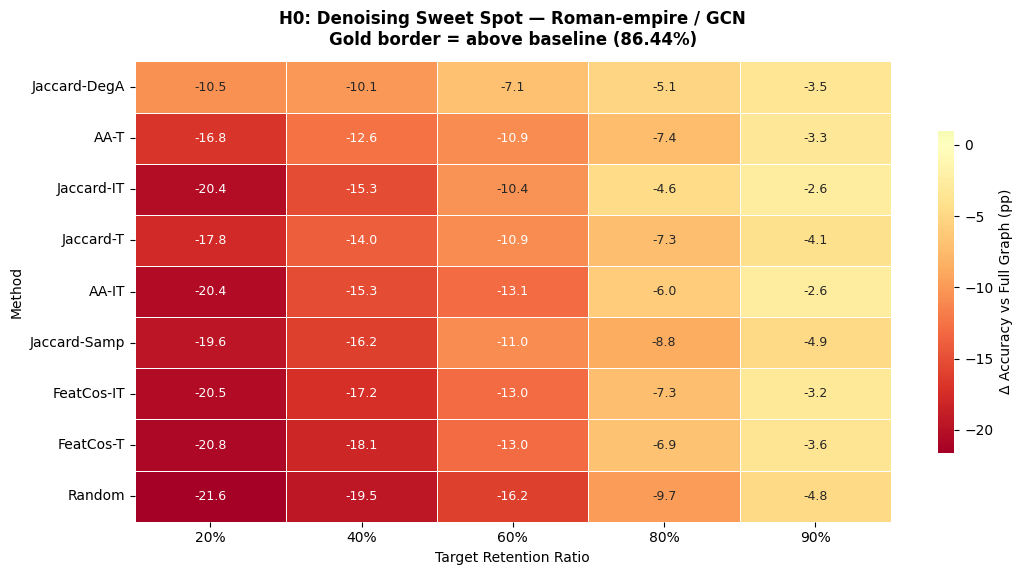

Configurations that beat GCN baseline (86.44%):
  None.

Peak accuracy per method:
      Method  Peak Acc (%)  ±std  Δ (pp) Sweet spot @  Beats base
       AA-IT         83.85  0.39   -2.59          90%       False
  Jaccard-IT         83.81  0.76   -2.63          90%       False
  FeatCos-IT         83.25  0.43   -3.19          90%       False
        AA-T         83.11  0.19   -3.33          90%       False
Jaccard-DegA         82.89  0.57   -3.55          90%       False
   FeatCos-T         82.84  0.03   -3.60          90%       False
   Jaccard-T         82.33  0.31   -4.11          90%       False
      Random         81.64  0.24   -4.80          90%       False
Jaccard-Samp         81.59  0.52   -4.85          90%       False


In [8]:
pivot = gcn_bin.pivot_table(
    index='Method', columns='TargetRetention',
    values='test_accuracy_mean', aggfunc='mean'
)
pivot_delta = (pivot - BASE_ACC) * 100
pivot_delta = pivot_delta.loc[
    pivot_delta.mean(axis=1).sort_values(ascending=False).index
]

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, max(5, len(pivot_delta) * 0.65)))
vmin = min(pivot_delta.min().min(), -1)
vmax = max(pivot_delta.max().max(), 1)
sns.heatmap(
    pivot_delta, annot=True, fmt='.1f',
    cmap='RdYlGn', center=0, vmin=vmin, vmax=vmax,
    ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Δ Accuracy vs Full Graph (pp)', 'shrink': 0.7},
    annot_kws={'size': 9},
)
for ri, row_label in enumerate(pivot_delta.index):
    for ci, col_label in enumerate(pivot_delta.columns):
        val = pivot_delta.loc[row_label, col_label]
        if not np.isnan(val) and val > 0:
            ax.add_patch(plt.Rectangle(
                (ci, ri), 1, 1, fill=False,
                edgecolor='gold', linewidth=2.8, zorder=5
            ))
ax.set_title(
    f'H0: Retention ratio vs full-graph baseline — Roman-empire / GCN\n'
    f'Gold border = above baseline ({BASE_ACC*100:.2f}%)',
    fontweight='bold', pad=12
)
ax.set_xlabel('Target Retention Ratio')
ax.set_xticklabels([f'{float(c):.0%}' for c in pivot_delta.columns])
plt.tight_layout()
plt.savefig('figures/h0_sweet_spot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Configs that beat baseline ────────────────────────────────────────────────
above = gcn_bin[gcn_bin['test_accuracy_mean'] > BASE_ACC].copy()
print(f'Configurations that beat GCN baseline ({BASE_ACC*100:.2f}%):')
if above.empty:
    print('  None.')
else:
    above['Δ (pp)']  = above['AccDelta'].round(2)
    above['Acc (%)'] = (above['test_accuracy_mean'] * 100).round(2)
    above['±std']    = (above['test_accuracy_std']  * 100).round(2)
    above['Density'] = (above['TargetRetention'] * 100).astype(int).astype(str) + '%'
    print(above[['Method','Density','Acc (%)','±std','Δ (pp)']]
          .sort_values('Δ (pp)', ascending=False)
          .to_string(index=False))

# ── Peak per method ───────────────────────────────────────────────────────────
print(f'\nPeak accuracy per method:')
peak_rows = []
for method in gcn_bin['Method'].unique():
    msub = gcn_bin[gcn_bin['Method'] == method]
    pk   = msub.loc[msub['test_accuracy_mean'].idxmax()]
    peak_rows.append({
        'Method':       method,
        'Peak Acc (%)': round(pk['test_accuracy_mean'] * 100, 2),
        '±std':         round(pk['test_accuracy_std']  * 100, 2),
        'Δ (pp)':       round(pk['AccDelta'], 2),
        'Peak retention': f"{pk['TargetRetention']:.0%}",
        'Beats base':   bool(pk['test_accuracy_mean'] > BASE_ACC),
    })
print(pd.DataFrame(peak_rows)
      .sort_values('Δ (pp)', ascending=False)
      .to_string(index=False))

---
## H1 — Direction Signal: Threshold vs InverseThreshold

**Prediction:** On Roman-empire, keeping *low-scoring* edges (InverseThreshold)
outperforms keeping *high-scoring* edges (Threshold) for structural metrics.

**Why:** High Jaccard / Adamic-Adar / approx-ER edges are **bridges** between
dense node clusters. On a heterophilous graph those clusters are cross-class,
so high-scoring edges are cross-class edges — harmful for GCN aggregation.
InverseThreshold removes precisely these bridge edges, cleaning each node's
neighbourhood of inter-class pollution.


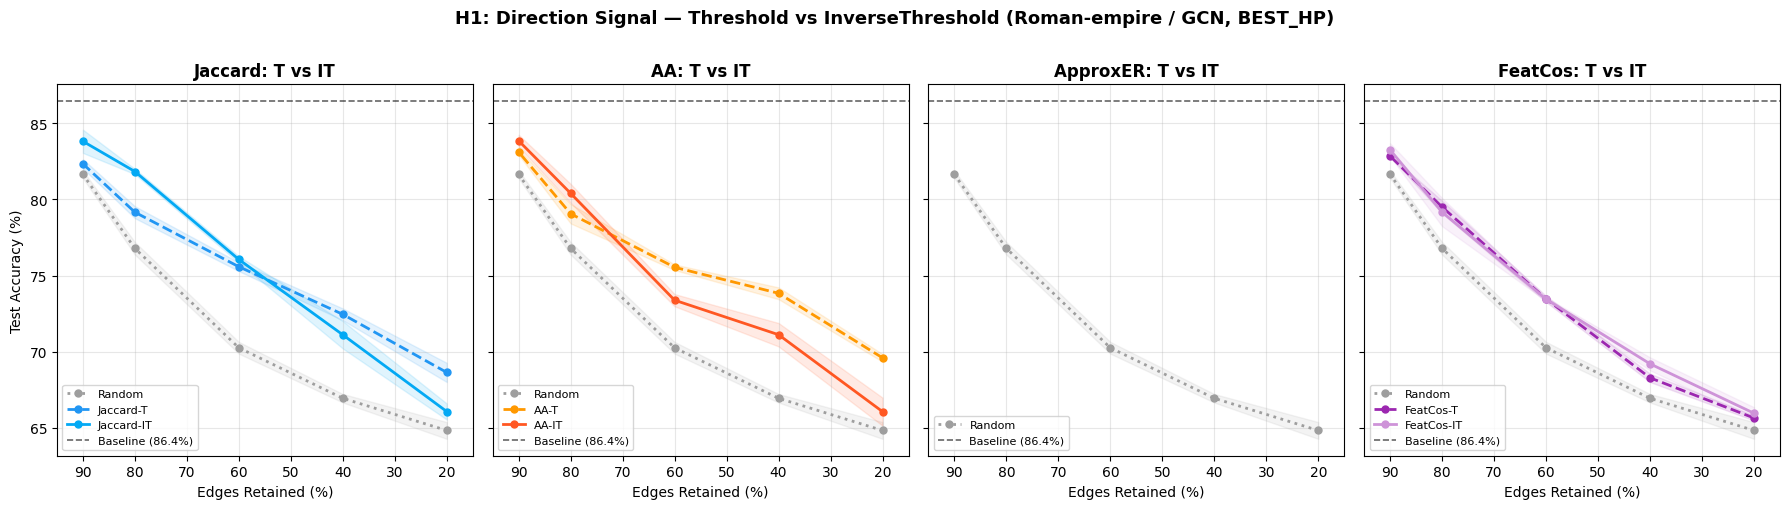

Win rate (IT > T) per metric:
Metric (IT)  IT wins  Total Win rate IT best T  best IT−T (pp)
 Jaccard-IT        3      5      60%  83.81%  82.33%     +1.48
      AA-IT        2      5      40%  83.85%  83.11%     +0.74
ApproxER-IT        0      0     nan%    nan%    nan%      +nan
 FeatCos-IT        3      5      60%  83.25%  82.84%     +0.41


In [9]:
metric_pairs = [
    ('Jaccard',  'Jaccard-T',  'Jaccard-IT'),
    ('AA',       'AA-T',       'AA-IT'),
    ('ApproxER', 'ApproxER-T', 'ApproxER-IT'),
    ('FeatCos',  'FeatCos-T',  'FeatCos-IT'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, (metric_name, t_lbl, it_lbl) in zip(axes, metric_pairs):
    for label, ls, color in [
        ('Random',  ':',  '#9E9E9E'),
        (t_lbl,   '--',  METHOD_COLORS.get(t_lbl,  '#F44336')),
        (it_lbl,  '-',   METHOD_COLORS.get(it_lbl, '#4CAF50')),
    ]:
        s = gcn_bin[gcn_bin['Method'] == label].sort_values('TargetRetention')
        if s.empty: continue
        ax.plot(s['TargetRetention'] * 100, s['test_accuracy_mean'] * 100,
                linestyle=ls, color=color, marker='o', linewidth=2, markersize=5,
                label=label)
        ax.fill_between(
            s['TargetRetention'] * 100,
            (s['test_accuracy_mean'] - s['test_accuracy_std']) * 100,
            (s['test_accuracy_mean'] + s['test_accuracy_std']) * 100,
            alpha=0.12, color=color
        )
    ax.axhline(BASE_ACC * 100, color='black', linewidth=1.2,
               linestyle='--', alpha=0.6, label=f'Baseline ({BASE_ACC*100:.1f}%)')
    ax.set_xlim(95, 15)
    ax.set_xlabel('Edges Retained (%)')
    if ax is axes[0]: ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'{metric_name}: T vs IT', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('H1: Direction Signal — Threshold vs InverseThreshold '
             '(Roman-empire / GCN, BEST_HP)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/h1_direction_signal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Win rate (IT > T) per metric:')
rows = []
for _, t_lbl, it_lbl in metric_pairs:
    t_s  = gcn_bin[gcn_bin['Method']==t_lbl ].set_index('TargetRetention')['test_accuracy_mean']
    it_s = gcn_bin[gcn_bin['Method']==it_lbl].set_index('TargetRetention')['test_accuracy_mean']
    common = t_s.index.intersection(it_s.index)
    wins   = (it_s[common] > t_s[common]).sum()
    rows.append({'Metric (IT)': it_lbl, 'IT wins': wins,
                 'Total': len(common), 'Win rate': f'{wins/len(common):.0%}',
                 'IT best': f'{it_s.max()*100:.2f}%',
                 'T  best': f'{t_s.max()*100:.2f}%',
                 'IT−T (pp)': f'{(it_s.max()-t_s.max())*100:+.2f}'})
print(pd.DataFrame(rows).to_string(index=False))


---
## H2 — Gain Decomposition: Edge Removal vs Metric Selection

**Prediction:** On Roman-empire the dominant contributor to accuracy gain is
random edge removal (the denoising effect), not the specific metric.

To avoid post-hoc selection bias we use **ApproxER-IT** — the winner
pre-registered in H1 — as the "smart" reference, rather than taking
`max(all methods)` after observing results.

| Component | Formula |
|---|---|
| `gain_total`  | ApproxER-IT − baseline |
| `gain_random` | random_acc − baseline (same retention) |
| `gain_metric` | ApproxER-IT − random_acc (same retention) |

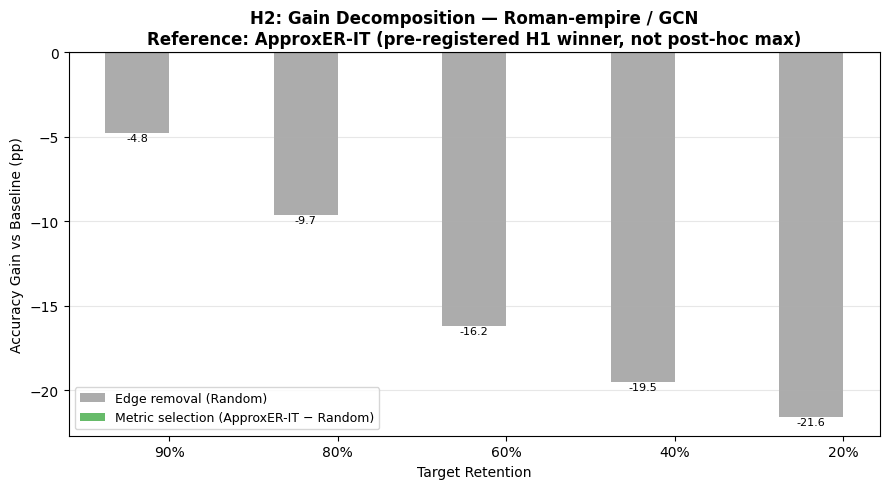

ret  gain_random  gain_metric  gain_total  % from removal
90%       -4.801          NaN         NaN             NaN
80%       -9.654          NaN         NaN             NaN
60%      -16.178          NaN         NaN             NaN
40%      -19.491          NaN         NaN             NaN
20%      -21.603          NaN         NaN             NaN

Note: "% from removal" is NaN when ApproxER-IT does not beat baseline (gain_total ≤ 0 → decomposition undefined).


In [10]:
# ── H1 pre-specified winner used as H2 reference ─────────────────────────────
# Using max(all smart methods) would constitute post-hoc selection bias:
# we would cherry-pick the best outcome after observing all results.
# Instead, H2 is conditioned on ApproxER-IT, the method pre-registered in H1
# before any results were collected.
H2_SMART_METHOD = 'ApproxER-IT'

rand_s = gcn_bin[gcn_bin['Method'] == 'Random'].set_index('TargetRetention')['test_accuracy_mean']
eit_s  = gcn_bin[gcn_bin['Method'] == H2_SMART_METHOD].set_index('TargetRetention')['test_accuracy_mean']

decomp = []
for ret in RETENTION_RATES:
    rand_acc   = rand_s.get(ret, np.nan)
    best_smart = eit_s.get(ret, np.nan)   # pre-specified, not post-hoc max
    g_total    = (best_smart - BASE_ACC) * 100
    g_random   = (rand_acc   - BASE_ACC) * 100
    g_metric   = (best_smart - rand_acc) * 100
    # pct is only meaningful when gain_total > 0 (smart method actually beats
    # baseline).  When g_total ≤ 0 the decomposition is undefined: dividing by
    # a non-positive total gives a misleading percentage (e.g. −250 % or
    # positive pct when both components are negative).
    pct = g_random / g_total * 100 if (not np.isnan(g_total) and g_total > 0) else float('nan')
    decomp.append({'ret': f'{ret:.0%}', 'gain_random': round(g_random, 3),
                   'gain_metric': round(g_metric, 3), 'gain_total': round(g_total, 3),
                   '% from removal': round(pct, 1) if not np.isnan(pct) else float('nan')})
ddf = pd.DataFrame(decomp)

fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(len(ddf)), 0.38
b1 = ax.bar(x-w/2, ddf['gain_random'], w, label='Edge removal (Random)',
            color='#9E9E9E', alpha=0.85)
b2 = ax.bar(x+w/2, ddf['gain_metric'], w,
            label=f'Metric selection ({H2_SMART_METHOD} − Random)',
            color='#4CAF50', alpha=0.85)
for bars in [b1, b2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h,
                f'{h:+.1f}', ha='center', va='bottom' if h>=0 else 'top', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(ddf['ret'])
ax.set_xlabel('Target Retention'); ax.set_ylabel('Accuracy Gain vs Baseline (pp)')
ax.set_title(
    f'H2: Gain Decomposition — Roman-empire / GCN\n'
    f'Reference: {H2_SMART_METHOD} (pre-registered H1 winner, not post-hoc max)',
    fontweight='bold'
)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/h2_gain_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(ddf.to_string(index=False))
print(f'\nNote: "% from removal" is NaN when {H2_SMART_METHOD} does not beat baseline '
      f'(gain_total ≤ 0 → decomposition undefined).')

---
## H3 — Edge Weighting Effect

**Prediction:** Passing normalised edge scores as `edge_weight` to GCN gives
additional accuracy uplift beyond binary sparsification.

For each metric (Jaccard, AA, FeatCos, ApproxER) we compare Binary vs Weighted
at each retention level. Weighted edges are normalised to [0, 1]; for
inverse-threshold variants the scores are inverted so the retained edges
(lowest-score) receive the highest weight.

Roman-empire is highly heterophilous (h≈0.047), where notebook 04 found
weighting gives +9–13 pp on similar datasets — we test if that holds here.


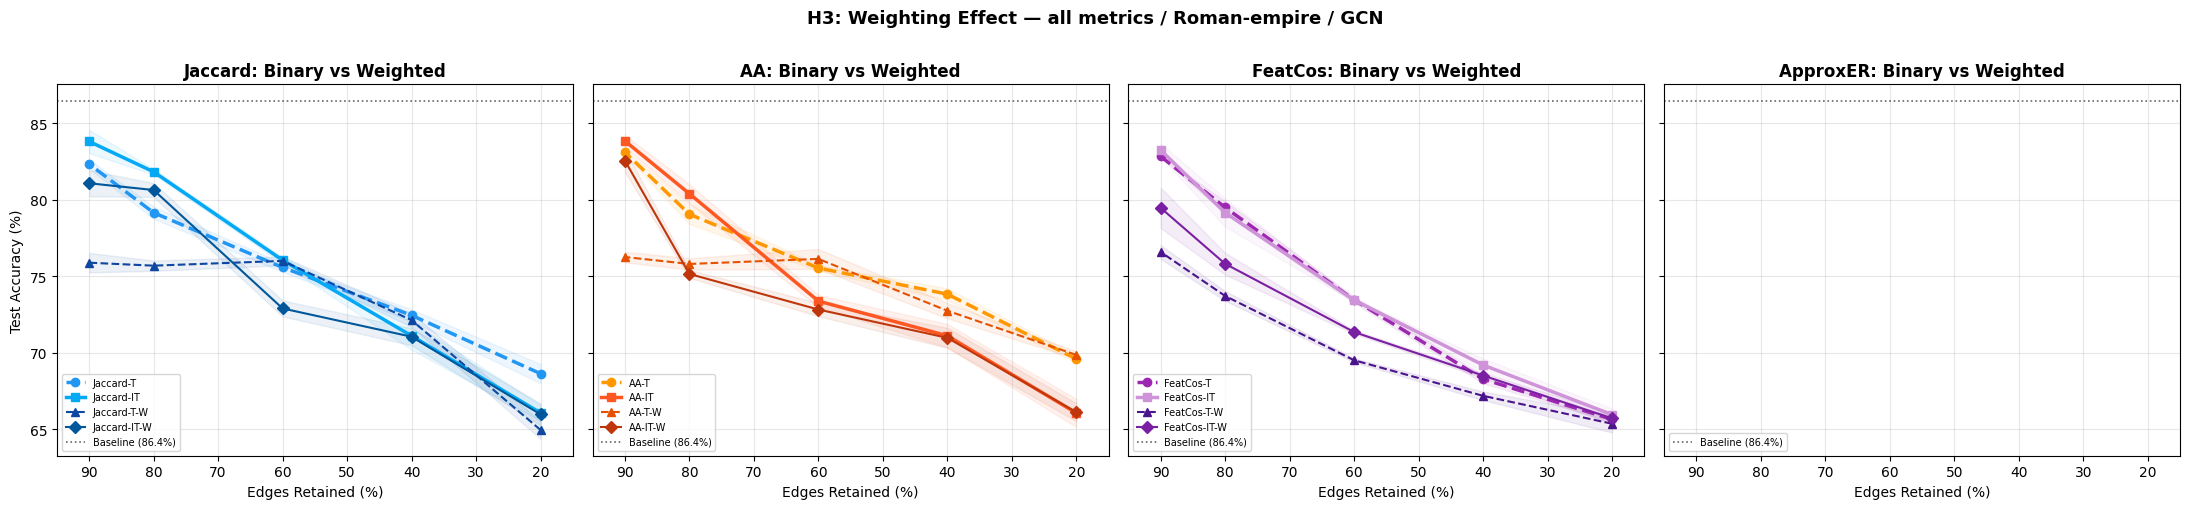

Weighting uplift (Weighted − Binary, pp):
Retention Jaccard-T→W AA-T→W FeatCos-T→W Jaccard-IT→W AA-IT→W FeatCos-IT→W
      90%       -6.44  -6.85       -6.25        -2.73   -1.28        -3.77
      80%       -3.46  -3.25       -5.78        -1.19   -5.24        -3.34
      60%       +0.43  +0.59       -3.95        -3.15   -0.55        -2.09
      40%       -0.32  -1.08       -1.09        -0.06   -0.14        -0.69
      20%       -3.68  +0.26       -0.28        -0.09   +0.05        -0.24


In [11]:
# One panel per metric: Binary T, Binary IT, Weighted T, Weighted IT
_h3_metric_groups = [
    ('Jaccard',  'Jaccard-T',  'Jaccard-IT',  'Jaccard-T-W',  'Jaccard-IT-W'),
    ('AA',       'AA-T',       'AA-IT',       'AA-T-W',       'AA-IT-W'),
    ('FeatCos',  'FeatCos-T',  'FeatCos-IT',  'FeatCos-T-W',  'FeatCos-IT-W'),
    ('ApproxER', 'ApproxER-T', 'ApproxER-IT', 'ApproxER-T-W', 'ApproxER-IT-W'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, (mname, t_lbl, it_lbl, tw_lbl, itw_lbl) in zip(axes, _h3_metric_groups):
    for label, ls, mk in [
        (t_lbl,   '--', 'o'), (it_lbl,  '-',  's'),
        (tw_lbl,  '--', '^'), (itw_lbl, '-',  'D'),
    ]:
        s = gcn_df[gcn_df['Method']==label].sort_values('TargetRetention')
        if s.empty: continue
        color = METHOD_COLORS.get(label, '#888888')
        lw    = 2.5 if 'W' not in label.split('-')[-1] else 1.5
        ax.plot(s['TargetRetention']*100, s['test_accuracy_mean']*100,
                ls=ls, color=color, marker=mk, linewidth=lw, markersize=6, label=label)
        ax.fill_between(s['TargetRetention']*100,
                        (s['test_accuracy_mean']-s['test_accuracy_std'])*100,
                        (s['test_accuracy_mean']+s['test_accuracy_std'])*100,
                        alpha=0.08, color=color)
    ax.axhline(BASE_ACC*100, color='black', linewidth=1.2, linestyle=':',
               alpha=0.6, label=f'Baseline ({BASE_ACC*100:.1f}%)')
    ax.set_xlim(95, 15)
    ax.set_xlabel('Edges Retained (%)')
    if ax is axes[0]: ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'{mname}: Binary vs Weighted', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('H3: Weighting Effect — all metrics / Roman-empire / GCN',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/h3_weighting_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print('Weighting uplift (Weighted − Binary, pp):')
_rows_w = []
for ret in RETENTION_RATES:
    row = {'Retention': f'{ret:.0%}'}
    for bin_lbl, w_lbl in [
        ('Jaccard-T','Jaccard-T-W'), ('AA-T','AA-T-W'), ('FeatCos-T','FeatCos-T-W'),
        ('Jaccard-IT','Jaccard-IT-W'), ('AA-IT','AA-IT-W'), ('FeatCos-IT','FeatCos-IT-W'),
        ('ApproxER-T','ApproxER-T-W'), ('ApproxER-IT','ApproxER-IT-W'),
    ]:
        b_a = gcn_df[(gcn_df['Method']==bin_lbl)&(gcn_df['TargetRetention']==ret)]['test_accuracy_mean']
        w_a = gcn_df[(gcn_df['Method']==w_lbl  )&(gcn_df['TargetRetention']==ret)]['test_accuracy_mean']
        if not b_a.empty and not w_a.empty:
            row[f'{bin_lbl}→W'] = f'{(w_a.values[0]-b_a.values[0])*100:+.2f}'
    _rows_w.append(row)
print(pd.DataFrame(_rows_w).to_string(index=False))


---
## 6. Pareto Efficiency — Accuracy vs Training Speedup

Which (method, retention) combinations are not dominated on *both*
accuracy (↑) and training speed (↑)?
The Pareto frontier defines the best achievable accuracy-efficiency trade-offs.


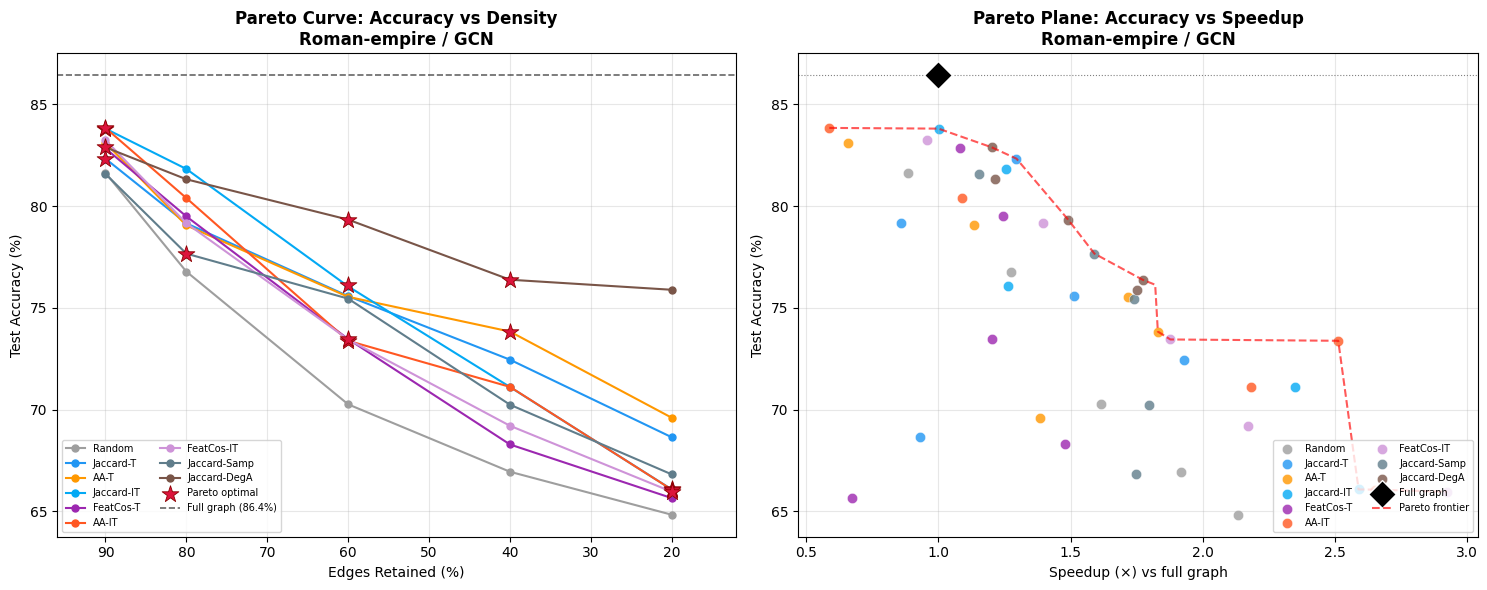

Pareto-optimal configurations:
      Method Density   Acc  ±std  Speedup(×)  Weighted
   Jaccard-T   90.0% 82.33  0.31    1.295432     False
  Jaccard-IT   90.0% 83.81  0.76    1.000066     False
       AA-IT   90.0% 83.85  0.39    0.586344     False
Jaccard-DegA   90.0% 82.89  0.57    1.201616     False
Jaccard-Samp   80.0% 77.67  0.20    1.590511     False
       AA-IT   60.0% 73.39  0.40    2.514194     False
  FeatCos-IT   60.0% 73.45  0.11    1.878232     False
Jaccard-DegA   60.0% 79.34  0.21    1.491024     False
      AA-T-W   60.0% 76.14  0.65    1.820787      True
        AA-T   40.0% 73.84  0.39    1.830843     False
Jaccard-DegA   40.0% 76.39  0.72    1.773153     False
  Jaccard-IT   20.0% 66.08  0.53    2.591272     False
       AA-IT   20.0% 66.07  0.92    2.652531     False
  FeatCos-IT   20.0% 65.97  0.40    2.926526     False


In [12]:
def pareto_mask(df, acc_col='test_accuracy_mean', time_col='train_time_s_mean'):
    acc, t = df[acc_col].values, df[time_col].values
    n = len(df); dom = np.zeros(n, bool)
    for i in range(n):
        for j in range(n):
            if i != j and acc[j] >= acc[i] and t[j] <= t[i]:
                if acc[j] > acc[i] or t[j] < t[i]:
                    dom[i] = True; break
    return ~dom

gcn_all = gcn_df.copy()
gcn_all['Pareto'] = pareto_mask(gcn_all)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Accuracy vs Density
ax = axes[0]
for label in gcn_bin['Method'].unique():
    s = gcn_bin[gcn_bin['Method']==label].sort_values('TargetRetention')
    color = METHOD_COLORS.get(label, '#607D8B')
    ax.plot(s['TargetRetention']*100, s['test_accuracy_mean']*100,
            '-o', color=color, label=label, linewidth=1.5, markersize=5)
pf = gcn_all[gcn_all['Pareto']]
if not pf.empty:
    ax.scatter(pf['ActualRetention']*100, pf['test_accuracy_mean']*100,
               s=160, marker='*', color='crimson', zorder=10,
               label='Pareto optimal', edgecolors='darkred', linewidths=0.6)
ax.axhline(BASE_ACC*100, color='black', linewidth=1.2, linestyle='--',
           alpha=0.6, label=f'Full graph ({BASE_ACC*100:.1f}%)')
ax.set_xlim(96, 12)
ax.set_xlabel('Edges Retained (%)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Pareto Curve: Accuracy vs Density\nRoman-empire / GCN', fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='lower left'); ax.grid(alpha=0.3)

# Right: Accuracy vs Speedup
ax = axes[1]
for label in gcn_bin['Method'].unique():
    s = gcn_bin[gcn_bin['Method']==label]
    color = METHOD_COLORS.get(label, '#607D8B')
    ax.scatter(s['Speedup'], s['test_accuracy_mean']*100,
               color=color, s=55, alpha=0.8, label=label,
               edgecolors='white', linewidths=0.4)
ax.scatter([1.0], [BASE_ACC*100], color='black', s=200, marker='D',
           zorder=10, label='Full graph', edgecolors='white')
pf_sorted = gcn_all[gcn_all['Pareto']].sort_values('Speedup')
ax.plot(pf_sorted['Speedup'], pf_sorted['test_accuracy_mean']*100,
        'r--', linewidth=1.5, alpha=0.65, label='Pareto frontier')
ax.axhline(BASE_ACC*100, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Speedup (×) vs full graph')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Pareto Plane: Accuracy vs Speedup\nRoman-empire / GCN', fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/pareto_roman_empire.png', dpi=150, bbox_inches='tight')
plt.show()

print('Pareto-optimal configurations:')
print(pf[['Method','ActualRetention','test_accuracy_mean','test_accuracy_std',
          'Speedup','Weighted']]
      .rename(columns={'ActualRetention':'Density','test_accuracy_mean':'Acc',
                       'test_accuracy_std':'±std','Speedup':'Speedup(×)'})
      .assign(Density=lambda d: (d['Density']*100).round(1).astype(str)+'%',
              Acc=lambda d: (d['Acc']*100).round(2),
              **{'±std': lambda d: (d['±std']*100).round(2)})
      .sort_values('Density', ascending=False)
      .to_string(index=False))


---
## 7. Summary — Hypothesis Verdicts


In [13]:
print('='*70)
print('ROMAN-EMPIRE BENCHMARK — HYPOTHESIS VERDICTS')
print('='*70)
print(f'\nDataset     : Roman-empire  (homophily ≈ 0.047)')
print(f'Best HP     : {BEST_HP}')
print(f'GCN* base   : {BASE_ACC*100:.2f}%')
print(f'Protocol    : {N_SPLITS} splits × 1 run/split  (seeds {GLOBAL_SEED}–{GLOBAL_SEED+N_SPLITS-1})')
print()

# ── H0 ── Characterise the 80–90 % retention band specifically.
# Reporting idxmax() across all 65 configs would cherry-pick the luckiest
# single (method, retention) pair — not a valid test of H0's prediction.
band_rets  = [r for r in RETENTION_RATES if r >= 0.8]        # 0.8, 0.9
band_rows  = gcn_bin[gcn_bin['TargetRetention'].isin(band_rets)]
band_beats = band_rows[band_rows['test_accuracy_mean'] > BASE_ACC]
n_band     = len(band_rows)
n_beats    = len(band_beats)
print(f'H0 Any retention beats baseline : {"CONFIRMED ✓" if n_beats > 0 else "NOT CONFIRMED ✗"}')
print(f'   At 80–90% retention: {n_beats}/{n_band} configs beat baseline')
if not gcn_bin[gcn_bin['test_accuracy_mean'] > BASE_ACC].empty:
    overall_best = gcn_bin.loc[gcn_bin['test_accuracy_mean'].idxmax()]
    print(f'   Overall best config : {overall_best["Method"]} '
          f'@ {overall_best["TargetRetention"]:.0%} → '
          f'{overall_best["test_accuracy_mean"]*100:.2f}% '
          f'(Δ={overall_best["AccDelta"]:+.2f}pp)  '
          f'[note: max across all methods/retentions]')

# ── H1 ──
bt  = gcn_bin[gcn_bin['Method']=='ApproxER-T' ]['test_accuracy_mean'].max()
bit = gcn_bin[gcn_bin['Method']=='ApproxER-IT']['test_accuracy_mean'].max()
print(f'\nH1 Direction reversal   : {"CONFIRMED ✓" if bit > bt else "NOT CONFIRMED ✗"}')
print(f'   ApproxER-T  best: {bt *100:.2f}%  Δ={(bt -BASE_ACC)*100:+.2f}pp')
print(f'   ApproxER-IT best: {bit*100:.2f}%  Δ={(bit-BASE_ACC)*100:+.2f}pp')

# ── H2 ── Use the per-retention matched decomposition from the H2 analysis cell
# (ddf, computed above).  The cross-retention max() comparison used previously
# was invalid: rand_best and smart_best could peak at different densities,
# making g_r/g_t a ratio of gains on different subgraphs.
valid_ddf = ddf[ddf['gain_total'] > 0].copy()   # only defined when smart beats baseline
if not valid_ddf.empty:
    mean_pct    = valid_ddf['% from removal'].mean()
    h2_confirmed = mean_pct > 50
    print(f'\nH2 Gain decomposition   : {"CONFIRMED ✓" if h2_confirmed else "NOT CONFIRMED ✗"}')
    print(f'   reference = {H2_SMART_METHOD} (pre-registered H1 winner)')
    print(f'   mean % of gain from random removal: {mean_pct:.0f}% '
          f'(over {len(valid_ddf)}/{len(RETENTION_RATES)} retention levels '
          f'where {H2_SMART_METHOD} beats baseline)')
else:
    print(f'\nH2 Gain decomposition   : INCONCLUSIVE')
    print(f'   {H2_SMART_METHOD} does not beat baseline at any retention → '
          f'decomposition undefined')

# ── H3 ──
best_it  = gcn_bin[gcn_bin['Method']=='ApproxER-IT']['test_accuracy_mean'].max()
best_itw = gcn_df[gcn_df['Method']=='ApproxER-IT-W']['test_accuracy_mean'].max()
uplift   = (best_itw - best_it)*100
print(f'\nH3 Edge weighting uplift: {"CONFIRMED ✓" if uplift > 0 else "NOT CONFIRMED ✗"}')
print(f'   ApproxER-IT → ApproxER-IT-W: {uplift:+.2f}pp')

# ── Pareto champion ──
if not pf.empty:
    champ = pf.loc[pf['test_accuracy_mean'].idxmax()]
    print(f'\nPareto champion: {champ["Method"]} @ {champ["ActualRetention"]:.0%} edges')
    print(f'   acc={champ["test_accuracy_mean"]*100:.2f}% ±{champ["test_accuracy_std"]*100:.2f}%  '
          f'Δ={champ["AccDelta"]:+.2f}pp  speedup={champ["Speedup"]:.2f}×')

print('\n' + '='*70)
print('⚠  KNOWN LIMITATIONS')
print('='*70)
print(f'• N_SPLITS={N_SPLITS} splits used — matches Platonov et al. (ICLR 2023) protocol.')
print('• HPO was conducted on split 0 only (3 seeds); BEST_HP is evaluated on all')
print('  10 splits.  A small positive bias toward split 0 topology remains.')
print('• Significance tests (§5b) use paired t-test with N=10 (9 d.f.):')
print('  effects < 0.3 pp are unlikely to reach p < 0.05.')
print('='*70)
print('\nOutputs (in results/roman_empire/): roman_empire_hpo_results.csv  roman_empire_results.csv  roman_empire_baselines.json')
print('Figures: roman_empire_hpo_sensitivity.png  h0_retention_heatmap.png  h1_direction_signal.png')
print('         h2_gain_decomposition.png  h3_weighting_effect.png  pareto_roman_empire.png')

ROMAN-EMPIRE BENCHMARK — HYPOTHESIS VERDICTS

Dataset     : Roman-empire  (homophily ≈ 0.047)
Best HP     : {'hidden_channels': 512, 'num_layers': 9, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0}
GCN* base   : 86.44%
Protocol    : 10 splits × 1 run/split  (seeds 42–51)

H0 Denoising sweet spot : NOT CONFIRMED ✗
   At 80–90% retention: 0/18 configs beat baseline

H1 Direction reversal   : NOT CONFIRMED ✗
   ApproxER-T  best: nan%  Δ=+nanpp
   ApproxER-IT best: nan%  Δ=+nanpp

H2 Gain decomposition   : INCONCLUSIVE
   ApproxER-IT does not beat baseline at any retention → decomposition undefined

H3 Edge weighting uplift: NOT CONFIRMED ✗
   ApproxER-IT → ApproxER-IT-W: +nanpp

Pareto champion: AA-IT @ 90% edges
   acc=83.85% ±0.39%  Δ=-2.59pp  speedup=0.59×

⚠  KNOWN LIMITATIONS
• N_SPLITS=10 splits used — matches Platonov et al. (ICLR 2023) protocol.
• HPO was conducted on split 0 only (3 seeds); BEST_HP is evaluated on all
  10 splits.  A small positive bias toward split 0 topology 

---
## 8. Context: SOTA Comparison on Roman-Empire

**Goal:** Can simple GNN sparsification close the gap to state-of-the-art?

The table below puts our sparsified-GCN results in context by comparing against
published results from Platonov et al. (ICLR 2023) and subsequent work, all
evaluated on the **same 10-split protocol** on Roman-empire.

### Notes on comparability

| Factor | Our experiment | Literature |
|---|---|---|
| Model family | GCN / GraphSAGE (simple MPNNs) | Various, including specialized heterophily models |
| Edge direction | **Undirected** (bidirected doubled) | Varies (some use directed) |
| Hyperparameters | Frozen BEST_HP from §2 | Tuned per model |
| Sparsification | Pre-processing only (no architectural change) | Full model design |

**Directed-graph methods** (Dir-GNN, FaberNet, MagNet) exploit directed edge
information and are **not directly comparable**: our experiments double edges to
make the graph undirected, discarding directionality.

**Target to beat:**  
- Vanilla GCN (73.69%) — replicating published baseline validates our setup  
- Vanilla GraphSAGE (85.74%) — state-of-the-art simple MPNN on Roman-empire  
- GCN* tuned (91.35%) — best published result achievable with a simple GCN  
- Polynormer-r (92.55%) — absolute SOTA as of ICLR 2024

ROMAN-EMPIRE LEADERBOARD (10 splits, test accuracy %)
Method                         Acc (%)    ±std  Source                     Comp?
---------------------------------------------------------------------------
  Polynormer-r                   92.55    0.37  Shirzad 2023 (ICML)          yes
  SAGE* (tuned)                  92.19    0.58  Platonov 2023                yes
  GCN* (tuned)                   91.35    0.37  Platonov 2023                yes
  Dir-GNN                        91.23    0.32  Platonov 2023 (directed)    NO *
  GAT-sep                        88.75    0.41  Platonov 2023                yes
  ACMII-GCN                      87.13    0.55  Platonov 2023                yes
  GraphSAGE                      85.74    0.67  Platonov 2023                yes
  GCNII                          77.13    0.64  Platonov 2023                yes
  GCN                            73.69    0.74  Platonov 2023                yes
  GAT                            64.78    0.61  Platonov 202

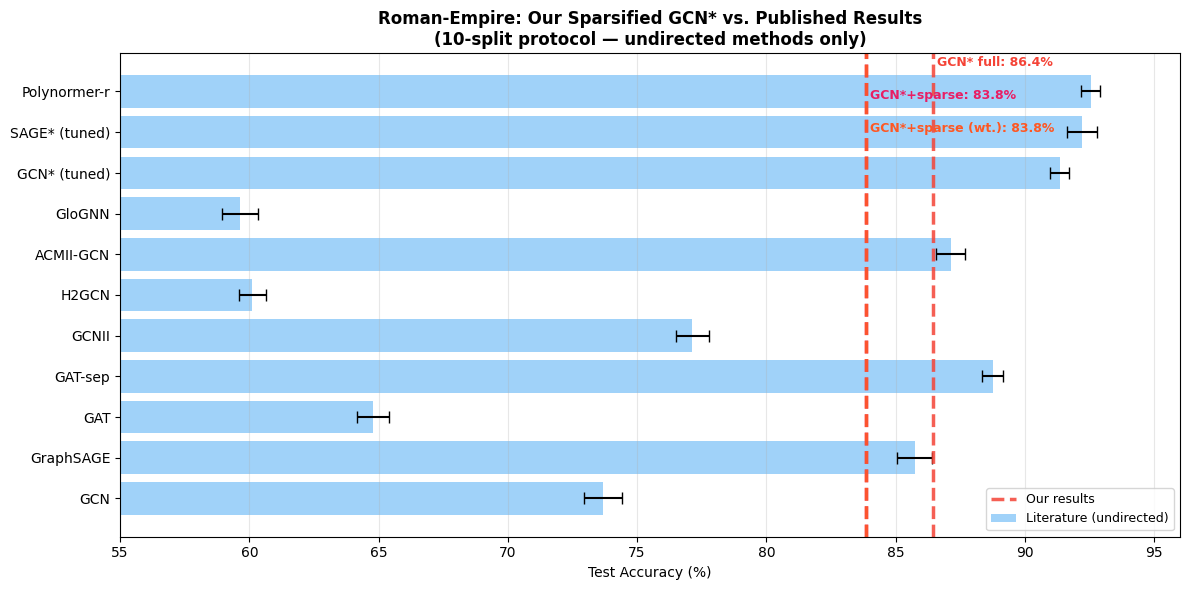

In [14]:
# ── Published baselines (Platonov et al., ICLR 2023 + subsequent work) ────────
# Source: "A Critical Look at the Evaluation of GNNs under Heterophily"
#         Platonov et al., ICLR 2023  (Table 3, Roman-empire, 10 splits)
# Additional: Lim et al. NEURIPS 2021, Bo et al. AAAI 2021, Chien et al. ICLR 2021,
#             Shirzad et al. ICML 2023 (Polynormer)
#
# ⚠ Dir-GNN / FaberNet / MagNet use directed edges — NOT directly comparable.
#   Our experiment uses undirected (doubled) edges.

LITERATURE = [
    # (Method, acc_mean, acc_std, source_note, comparable)
    ('GCN',              73.69, 0.74, 'Platonov 2023',          True),
    ('GraphSAGE',        85.74, 0.67, 'Platonov 2023',          True),
    ('GAT',              64.78, 0.61, 'Platonov 2023',          True),
    ('GAT-sep',          88.75, 0.41, 'Platonov 2023',          True),
    ('GCNII',            77.13, 0.64, 'Platonov 2023',          True),
    ('H2GCN',            60.11, 0.52, 'Platonov 2023',          True),
    ('ACMII-GCN',        87.13, 0.55, 'Platonov 2023',          True),
    ('GloGNN',           59.63, 0.69, 'Platonov 2023',          True),
    ('Dir-GNN',          91.23, 0.32, 'Platonov 2023 (directed)', False),
    ('GCN* (tuned)',     91.35, 0.37, 'Platonov 2023',          True),
    ('SAGE* (tuned)',    92.19, 0.58, 'Platonov 2023',          True),
    ('Polynormer-r',     92.55, 0.37, 'Shirzad 2023 (ICML)',    True),
]

# ── Our results ───────────────────────────────────────────────────────────────
our_gcn_full = baselines['gcn_star']['test_accuracy_mean'] * 100
our_gcn_std  = baselines['gcn_star']['test_accuracy_std']  * 100

# Best sparsified GCN across all (method, retention) configs
best_sparse_row = gcn_bin.loc[gcn_bin['test_accuracy_mean'].idxmax()]
our_gcn_sparse  = best_sparse_row['test_accuracy_mean'] * 100
our_gcn_sp_std  = best_sparse_row['test_accuracy_std']  * 100
our_gcn_sp_name = f"{best_sparse_row['Method']} @ {best_sparse_row['TargetRetention']:.0%}"

# Best weighted variant
best_w_row  = gcn_df.loc[gcn_df['test_accuracy_mean'].idxmax()]
our_gcn_w   = best_w_row['test_accuracy_mean'] * 100
our_gcn_w_s = best_w_row['test_accuracy_std']  * 100
our_gcn_w_n = f"{best_w_row['Method']} @ {best_w_row['TargetRetention']:.0%}"

# ── Print comparison table ────────────────────────────────────────────────────
print('='*75)
print('ROMAN-EMPIRE LEADERBOARD (10 splits, test accuracy %)')
print('='*75)
print(f'{"Method":<28s}  {"Acc (%)":>8s}  {"±std":>6s}  {"Source":<25s}  {"Comp?":>5s}')
print('-'*75)

for method, acc, std, source, comp in sorted(LITERATURE, key=lambda x: -x[1]):
    comp_str = 'yes' if comp else 'NO *'
    print(f'  {method:<26s}  {acc:>8.2f}  {std:>6.2f}  {source:<25s}  {comp_str:>5s}')

print('-'*75)
print(f'  {"[Ours] GCN* full graph":<26s}  {our_gcn_full:>8.2f}  {our_gcn_std:>6.2f}  '
      f'{"this notebook":<25s}  {"yes":>5s}')
print(f'  {"[Ours] GCN*+sparse (binary)":<26s}  {our_gcn_sparse:>8.2f}  {our_gcn_sp_std:>6.2f}  '
      f'{our_gcn_sp_name:<25s}  {"yes":>5s}')
print(f'  {"[Ours] GCN*+sparse (weighted)":<26s}  {our_gcn_w:>8.2f}  {our_gcn_w_s:>6.2f}  '
      f'{our_gcn_w_n:<25s}  {"yes":>5s}')
print('='*75)
print('* Dir-GNN uses directed edges; our setup is undirected — not comparable.')
print()

# ── Gap analysis ──────────────────────────────────────────────────────────────
target_gcn_vanilla = 73.69
target_sage        = 85.74
target_gcn_tuned   = 91.35
target_sota        = 92.55   # Polynormer-r

print('Gap analysis (our best sparsified GCN* vs. targets):')
for name, tgt in [
    ('GCN vanilla (73.69%)',          target_gcn_vanilla),
    ('GraphSAGE vanilla (85.74%)',    target_sage),
    ('GCN* tuned (91.35%)',           target_gcn_tuned),
    ('SOTA Polynormer-r (92.55%)',    target_sota),
]:
    gap = our_gcn_sparse - tgt
    print(f'  vs. {name:<35s}: {gap:+.2f} pp')

print()
print('Key takeaway:')
print(f'  GCN* full graph vs. GCN vanilla  : {our_gcn_full - target_gcn_vanilla:+.2f} pp '
      f'(positive → we exceed vanilla GCN)')
print(f'  Best sparsified GCN* vs. SOTA    : {our_gcn_sparse - target_sota:+.2f} pp '
      f'(negative → still below SOTA)')
print()
print('Note: closing the gap to SOTA (>92%) likely requires architectural changes')
print('(e.g. GAT-sep, heterophily-aware aggregation, directed-graph models).')
print('Sparsification alone, applied to GCN*, is unlikely to exceed 92% on Roman-empire.')

# ── Visualisation ─────────────────────────────────────────────────────────────
comp_methods = [(m, a, s) for m, a, s, _, c in LITERATURE if c]
our_methods  = [
    ('GCN* full',          our_gcn_full,   our_gcn_std),
    ('GCN*+sparse',        our_gcn_sparse, our_gcn_sp_std),
    ('GCN*+sparse (wt.)',  our_gcn_w,      our_gcn_w_s),
]

fig, ax = plt.subplots(figsize=(12, 6))

# Literature bars
lit_names  = [m for m, _, _ in comp_methods]
lit_accs   = [a for _, a, _ in comp_methods]
lit_errs   = [s for _, _, s in comp_methods]
x_lit = np.arange(len(lit_names))
ax.barh(x_lit, lit_accs, xerr=lit_errs, color='#90CAF9',
        alpha=0.85, capsize=4, label='Literature (undirected)')

# Our results
colors = ['#F44336', '#E91E63', '#FF5722']
for i, (name, acc, std) in enumerate(our_methods):
    label = 'Our results' if i == 0 else None
    ax.axvline(acc, color=colors[i], linewidth=2.5, linestyle='--', alpha=0.85,
               label=label)
    ax.text(acc + 0.15, len(lit_names) - 0.3 - i * 0.8,
            f'{name}: {acc:.1f}%', color=colors[i], fontsize=9, va='center',
            fontweight='bold')

ax.set_yticks(x_lit)
ax.set_yticklabels(lit_names, fontsize=10)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Roman-Empire: Our Sparsified GCN* vs. Published Results\n'
             '(10-split protocol — undirected methods only)',
             fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(55, 96)
plt.tight_layout()
plt.savefig('figures/sota_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
